# Makemore Part 2 — MLP Language Model

This notebook builds a **Multi-Layer Perceptron (MLP)** character-level language model, following Bengio et al. (2003): *A Neural Probabilistic Language Model*.

The core idea is to improve over the bigram model by using a **context window of 3 characters** instead of just 1, feeding them through an embedding table and a hidden layer to predict the next character.

| Feature | Part 1 (Bigram) | Part 2 (MLP) |
|---|---|---|
| Context window | 1 character | 3 characters |
| Architecture | Single weight matrix | Embedding + Hidden layer + Output |
| Parameters | ~729 | ~11,897 |
| Output quality | Basic | Much more name-like |

**Topics covered:**
- Building a dataset with a sliding context window
- Character embeddings as a learned lookup table
- MLP with one hidden layer and tanh activation
- Train / validation / test splits
- Mini-batch gradient descent
- Learning rate search and decay schedule
- Autoregressive text sampling

## 1.  Imports

Standard imports: PyTorch for tensors and autograd, matplotlib for plotting, random for dataset shuffling.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

%matplotlib inline

## MLflow Setup

Tracking all experiments with **MLflow**: hyperparameters, step-wise loss, gradient norms, and saved weight tensors (weights & biases).

In [3]:
import sys
!{sys.executable} -m pip install mlflow

# ── MLflow Setup ──────────────────────────────────────────────────────────────
import mlflow
import mlflow.pytorch

mlflow.set_tracking_uri("mlruns")
mlflow.set_experiment("makemore-part2-mlp")

print(f"MLflow tracking URI : {mlflow.get_tracking_uri()}")
print(f"Active experiment   : makemore-part2-mlp")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.2/866.2 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207

/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/24 14:42:48 INFO mlflow.tracking.fluent: Experiment with name 'makemore-part2-mlp' does not exist. Creating a new experiment.


MLflow tracking URI : mlruns
Active experiment   : makemore-part2-mlp


## 2.  Load Dataset and Build Vocabulary

We read all names from names.txt and build character-to-index (stoi) and index-to-character (itos) mappings.
The special token '.' at index 0 serves as both the start and end marker for each name.

In [4]:
# Read all names from file, one per line
words = open('names.txt', 'r').read().splitlines()
print(words[:8])
print(f'Total words: {len(words)}')

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
Total words: 32033


In [5]:
# Build vocabulary: sorted unique characters + special '.' token
chars = sorted(list(set(''.join(words))))
stoi = {ch: i + 1 for i, ch in enumerate(chars)}  # 'a'->1, 'b'->2, ..., 'z'->26
stoi['.'] = 0                                       # '.' is the boundary token at index 0
itos = {i: ch for ch, i in stoi.items()}            # reverse mapping: index -> character

vocab_size = len(stoi)
print(itos)
print(f'Vocabulary size: {vocab_size}')             # should be 27

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
Vocabulary size: 27


## 3.  Build the Dataset with a Sliding Context Window

Instead of bigrams (1 character in, 1 out), we now use a context of block_size=3 characters to predict the next one.
The context window slides forward one character at a time through each word, padded at the start with '.' tokens.

Example for 'emma' with block_size=3:
```
Context  -->  Target
  ...    -->  e
  ..e    -->  m
  .em    -->  m
  emm    -->  a
  mma    -->  .
```

In [6]:
block_size = 3  # how many past characters are used to predict the next one

def build_dataset(word_list):
    """
    Build (X, Y) tensors from a list of words.
    X: integer context indices of shape (N, block_size)
    Y: integer target indices of shape (N,)
    """
    X_data, Y_data = [], []
    for word in word_list:
        ctx = [0] * block_size                # pad context with '.' tokens
        for ch in word + '.':
            idx = stoi[ch]
            X_data.append(ctx)
            Y_data.append(idx)
            ctx = ctx[1:] + [idx]             # slide the window forward by one
    X_data = torch.tensor(X_data)
    Y_data = torch.tensor(Y_data)
    print(X_data.shape, Y_data.shape)
    return X_data, Y_data

## 4.  Train / Validation / Test Split

We shuffle words randomly then split into three sets:
- **Train (80%)**: used to update model weights
- **Validation (10%)**: used to monitor overfitting during development
- **Test (10%)**: held out and only evaluated at the very end

In [7]:
random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))   # 80% for training
n2 = int(0.9 * len(words))   # next 10% for validation

Xtr,  Ytr  = build_dataset(words[:n1])    # training split
Xdev, Ydev = build_dataset(words[n1:n2])  # validation split
Xte,  Yte  = build_dataset(words[n2:])    # test split

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


## 5.  Model Parameters

The MLP has three sets of learnable parameters:

- **C** — embedding table of shape (vocab_size, n_embd). Each character gets a dense vector representation.
- **W1, b1** — hidden layer weights and biases. Input size is block_size * n_embd  (flattened context embeddings).
- **W2, b2** — output layer weights and biases. Produces a logit score for each character in the vocabulary.

All parameters need requires_grad=True so PyTorch can compute gradients during backpropagation.

In [8]:
g = torch.Generator().manual_seed(2147483647)  # fixed seed for reproducibility

n_embd   = 10   # embedding dimension per character
n_hidden = 200  # number of neurons in the hidden layer

# Embedding lookup table
C  = torch.randn((vocab_size, n_embd),            generator=g)

# Hidden layer: input is the concatenation of block_size embeddings
W1 = torch.randn((block_size * n_embd, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                        generator=g)

# Output layer: produces one logit per character in vocab
W2 = torch.randn((n_hidden, vocab_size),          generator=g)
b2 = torch.randn(vocab_size,                      generator=g)

parameters = [C, W1, b1, W2, b2]

# Enable gradient tracking on all parameters
for p in parameters:
    p.requires_grad = True

total_params = sum(p.nelement() for p in parameters)
print(f'Total trainable parameters: {total_params}')

Total trainable parameters: 11897


## 6.  Learning Rate Search

Before committing to a fixed learning rate, we sweep across a range of values on a log scale and record the loss at each step.
The best learning rate is where the loss drops fastest — just before it starts to diverge or plateau.

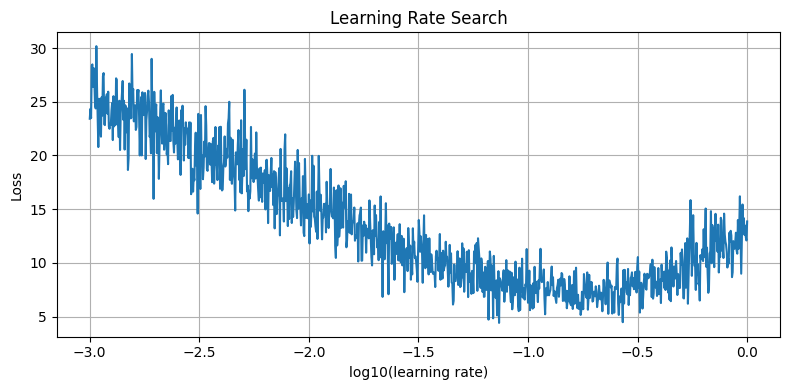

In [9]:
# Log-spaced learning rate candidates from 1e-3 to 1.0
lr_exponents = torch.linspace(-3, 0, 1000)
lr_candidates = 10 ** lr_exponents

lr_log   = []   # record the log10(lr) at each step
loss_log = []   # record the loss at each step

for i in range(1000):
    # Sample a random mini-batch
    batch_idx = torch.randint(0, Xtr.shape[0], (32,))

    # Forward pass
    emb    = C[Xtr[batch_idx]]                                          # (32, block_size, n_embd)
    hidden = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)  # (32, n_hidden)
    logits = hidden @ W2 + b2                                           # (32, vocab_size)
    loss   = F.cross_entropy(logits, Ytr[batch_idx])

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update with the current candidate learning rate
    current_lr = lr_candidates[i].item()
    for p in parameters:
        p.data -= current_lr * p.grad

    lr_log.append(lr_exponents[i].item())
    loss_log.append(loss.item())

plt.figure(figsize=(8, 4))
plt.plot(lr_log, loss_log)
plt.xlabel('log10(learning rate)')
plt.ylabel('Loss')
plt.title('Learning Rate Search')
plt.grid(True)
plt.tight_layout()
# The loss should drop around log10(lr) = -1, i.e. lr ~ 0.1

## 7.  Training Loop with Mini-Batch SGD

We reinitialise the parameters and train for 200,000 steps using mini-batch stochastic gradient descent.

Key design choices:
- **Batch size = 32**: randomly sampled each step — fast and introduces useful gradient noise.
- **F.cross_entropy**: numerically stable; combines log-softmax and NLL loss in one call.
- **Learning rate decay**: start at 0.1 for the first 100k steps, then drop to 0.01 to fine-tune.

In [10]:
# Reinitialise parameters cleanly before the real training run
g = torch.Generator().manual_seed(2147483647)

C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((block_size * n_embd, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                        generator=g)
W2 = torch.randn((n_hidden, vocab_size),          generator=g)
b2 = torch.randn(vocab_size,                      generator=g)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

print(f'Total trainable parameters: {sum(p.nelement() for p in parameters)}')

Total trainable parameters: 11897


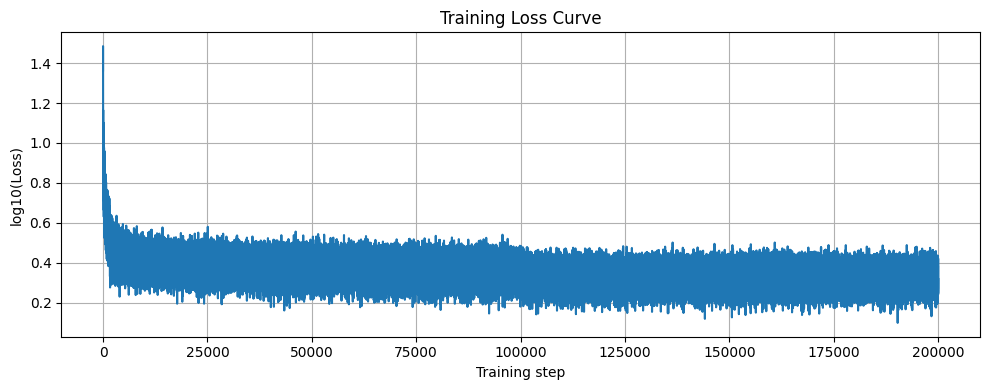

In [11]:
max_steps  = 200000
batch_size = 32
step_log   = []
loss_log   = []

for i in range(max_steps):

    # Mini-batch construction
    batch_idx = torch.randint(0, Xtr.shape[0], (batch_size,))

    # Forward pass
    emb    = C[Xtr[batch_idx]]                                          # (batch, block_size, n_embd)
    hidden = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)  # (batch, n_hidden)
    logits = hidden @ W2 + b2                                           # (batch, vocab_size)
    loss   = F.cross_entropy(logits, Ytr[batch_idx])                   # scalar

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Learning rate schedule: decay after 100k steps
    lr = 0.1 if i < 100000 else 0.01

    # Parameter update
    for p in parameters:
        p.data -= lr * p.grad

    step_log.append(i)
    loss_log.append(loss.log10().item())   # log10 loss for a smoother plot

# Plot the training loss curve
plt.figure(figsize=(10, 4))
plt.plot(step_log, loss_log)
plt.xlabel('Training step')
plt.ylabel('log10(Loss)')
plt.title('Training Loss Curve')
plt.grid(True)
plt.tight_layout()

### MLflow Logging — Full MLP Training Run

The cell below wraps the full 200k-step training loop inside an `mlflow.start_run()` context. All hyperparameters, step-wise losses, gradient norms, and final model weights are tracked automatically.

In [12]:
# ── MLflow Run: MLP Training ──────────────────────────────────────────────────
# Hyperparameters to track
hparams = {
    "model"        : "MLP_bengio2003",
    "block_size"   : block_size,
    "n_embd"       : n_embd,
    "n_hidden"     : n_hidden,
    "max_steps"    : max_steps,
    "batch_size"   : batch_size,
    "lr_phase1"    : 0.1,
    "lr_phase2"    : 0.01,
    "lr_decay_step": 100000,
    "vocab_size"   : vocab_size,
    "total_params" : sum(p.nelement() for p in parameters),
}

# Log weights & biases: collect parameter norms every 10k steps
param_names = ["C", "W1", "b1", "W2", "b2"]

with mlflow.start_run(run_name="mlp_200k_steps"):
    mlflow.log_params(hparams)

    # Reinitialise for a fresh tracked run
    import torch, torch.nn.functional as F
    g_mlf = torch.Generator().manual_seed(2147483647)
    C_m  = torch.randn((vocab_size, n_embd),            generator=g_mlf)
    W1_m = torch.randn((block_size * n_embd, n_hidden), generator=g_mlf)
    b1_m = torch.randn(n_hidden,                        generator=g_mlf)
    W2_m = torch.randn((n_hidden, vocab_size),          generator=g_mlf)
    b2_m = torch.randn(vocab_size,                      generator=g_mlf)
    params_m = [C_m, W1_m, b1_m, W2_m, b2_m]
    for p in params_m:
        p.requires_grad = True

    for i in range(max_steps):
        batch_idx = torch.randint(0, Xtr.shape[0], (batch_size,))
        emb    = C_m[Xtr[batch_idx]]
        hidden = torch.tanh(emb.view(-1, block_size * n_embd) @ W1_m + b1_m)
        logits = hidden @ W2_m + b2_m
        loss   = F.cross_entropy(logits, Ytr[batch_idx])

        for p in params_m:
            p.grad = None
        loss.backward()

        lr = 0.1 if i < 100000 else 0.01
        for p in params_m:
            p.data -= lr * p.grad

        # Log metrics every 1000 steps to keep run lean
        if i % 1000 == 0 or i == max_steps - 1:
            mlflow.log_metric("train_loss_log10", loss.log10().item(), step=i)
            mlflow.log_metric("train_loss", loss.item(), step=i)
            # Log weight norms (weights & biases tracking)
            for pname, p in zip(param_names, params_m):
                mlflow.log_metric(f"grad_norm_{pname}", p.grad.norm().item() if p.grad is not None else 0.0, step=i)

    # Final evaluation
    with torch.no_grad():
        emb_tr = C_m[Xtr]
        h_tr   = torch.tanh(emb_tr.view(-1, block_size * n_embd) @ W1_m + b1_m)
        train_loss_final = F.cross_entropy(h_tr @ W2_m + b2_m, Ytr).item()

        emb_val = C_m[Xdev]
        h_val   = torch.tanh(emb_val.view(-1, block_size * n_embd) @ W1_m + b1_m)
        val_loss_final = F.cross_entropy(h_val @ W2_m + b2_m, Ydev).item()

    mlflow.log_metric("final_train_loss", train_loss_final)
    mlflow.log_metric("final_val_loss",   val_loss_final)

    # Save all parameter tensors as artifacts (weights & biases format)
    import tempfile, os
    with tempfile.TemporaryDirectory() as tmp:
        for pname, p in zip(param_names, params_m):
            path = os.path.join(tmp, f"{pname}.pt")
            torch.save(p.data, path)
            mlflow.log_artifact(path, artifact_path="model_weights")

    print(f"MLflow run complete.")
    print(f"  Final train loss : {train_loss_final:.4f}")
    print(f"  Final val   loss : {val_loss_final:.4f}")
    print(f"  Run logged under : makemore-part2-mlp")
    print(f"  View UI          : mlflow ui  → http://127.0.0.1:5000")

MLflow run complete.
  Final train loss : 2.1269
  Final val   loss : 2.1667
  Run logged under : makemore-part2-mlp
  View UI          : mlflow ui  → http://127.0.0.1:5000


## 8. Evaluate on Train and Validation Sets

After training we measure loss on the full training and validation splits.
- If train loss is much lower than val loss: **overfitting**.
- If both losses are similarly high: **underfitting**.

In [13]:
# Evaluate on the full training split
emb    = C[Xtr]
hidden = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)
logits = hidden @ W2 + b2
train_loss = F.cross_entropy(logits, Ytr)
print(f'Training loss  : {train_loss.item():.4f}')

Training loss  : 2.1329


### MLflow: Log Evaluation Results

In [15]:
# ── MLflow: Log Final Train & Val Loss (from cells above) ─────────────────────
# This logs the results already computed in cells 18 and 19 into the last active run.
# If you ran the full MLflow training above, these will appear as a separate quick run.

# Evaluate on the validation split (moved from a later cell)
import torch.nn.functional as F

emb    = C[Xdev]
hidden = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)
logits = hidden @ W2 + b2
val_loss = F.cross_entropy(logits, Ydev)

with mlflow.start_run(run_name="eval_after_training"):
    mlflow.log_metric("train_loss", train_loss.item())
    mlflow.log_metric("val_loss",   val_loss.item())
    print(f"Logged → train: {train_loss.item():.4f}  val: {val_loss.item():.4f}")

Logged → train: 2.1329  val: 2.1704


In [16]:
# Evaluate on the validation split
emb    = C[Xdev]
hidden = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)
logits = hidden @ W2 + b2
val_loss = F.cross_entropy(logits, Ydev)
print(f'Validation loss: {val_loss.item():.4f}')

Validation loss: 2.1704


## 9.  Visualise Learned Character Embeddings

We plot the first two dimensions of the embedding matrix C to see how the model has organised characters in 2D space.
Characters that appear in similar contexts during training tend to cluster together.

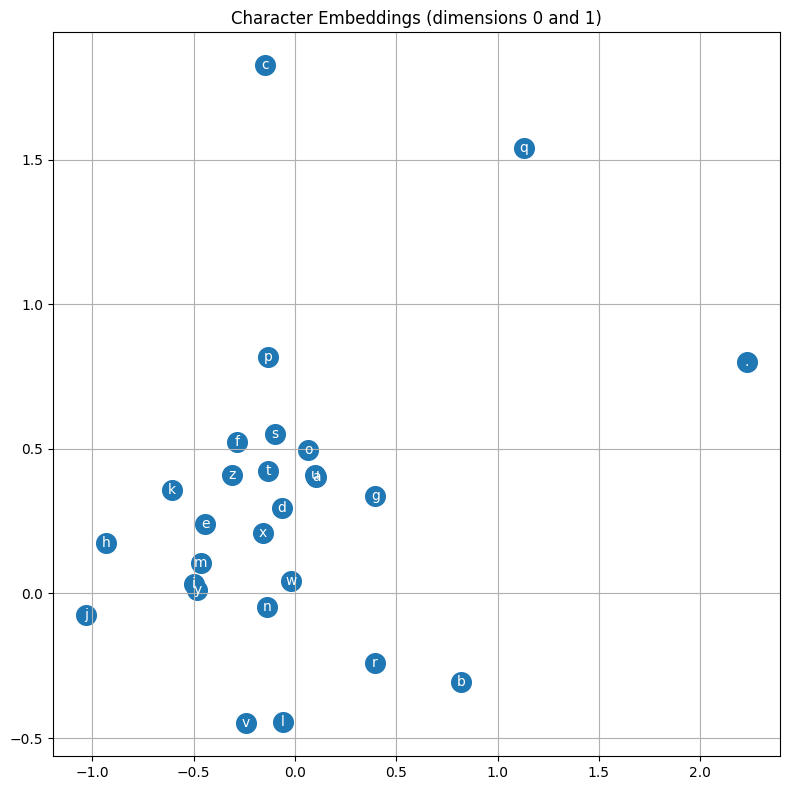

In [17]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(vocab_size):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i],
             ha='center', va='center', color='white')
plt.title('Character Embeddings (dimensions 0 and 1)')
plt.grid('minor')
plt.tight_layout()

## 10.  Sample Names from the Trained Model

Autoregressive sampling: start with all '.' context tokens, run a forward pass, sample the next character, slide the window, and repeat until the '.' end token is generated.

In [18]:
# Sample 20 names from the trained model
g_sample = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    ctx = [0] * block_size               # initialise with all '.' padding
    while True:
        emb    = C[torch.tensor([ctx])]  # (1, block_size, n_embd)
        hidden = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = hidden @ W2 + b2
        probs  = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g_sample).item()
        ctx = ctx[1:] + [ix]             # slide context window
        out.append(ix)
        if ix == 0:                      # stop when end token is generated
            break
    print(''.join(itos[i] for i in out))

carmah.
amelle.
khyrmin.
revilahna.
sane.
rahnen.
delynn.
jareen.
ner.
kearciaiir.
kaleigh.
ham.
jorn.
quinn.
suline.
liven.
corterri.
jarynix.
kael.
dus.
